# TPV Route Planning

Route optimisation for airborne meteorological surveys of Tropopause Polar Vortex (TPV) systems.

**Mission:** BASE → transit → observe TPV interior (parallel chords ⊥ major axis) → satellite coincidence segment → return to BASE

**Dependencies:** `numpy` `matplotlib` `shapely` `geopandas`

---

## Module structure

| Module | Cells | Content |
|--------|-------|---------|
| **1** | this file | Geometry utilities · PCA ellipse fit · candidate chord generation |
| 2 | — | Obstacle avoidance (Restricted Airspace) · Visibility graph · ATC zone penalty |
| 3 | — | Satellite coincidence segment · departure-time scheduling |
| 4 | — | Full route optimisation · dropsonde zone scoring · output |

All tunable parameters are defined at the top of the **Parameters** cell.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Polygon, Point
from shapely.ops import unary_union
from itertools import combinations
import heapq
from math import cos, sin, sqrt, pi, radians, degrees, atan2
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════════
# TUNABLE PARAMETERS  —  edit here only
# ════════════════════════════════════════════════════════════════════════════

AIRCRAFT_SPEED_KMH  = 850.0   # G3 cruise speed (km/h)
FLIGHT_TIME_H       = 5.0     # total mission time budget, including transit (hours)
TOTAL_BUDGET_KM     = AIRCRAFT_SPEED_KMH * FLIGHT_TIME_H   # 4 250 km

ATC_PENALTY_FACTOR  = 1.35    # effective-distance multiplier inside ATC zones (range 1.25–1.5)
TURN_PENALTY_MIN    = 7.5     # time penalty per heading change (minutes, range 5–10)
TURN_PENALTY_KM     = TURN_PENALTY_MIN / 60.0 * AIRCRAFT_SPEED_KMH   # ≈ 106 km
TURN_THRESHOLD_DEG  = 10.0   # minimum direction change (degrees) to count as a turn

MIN_LEG_SPACING_KM  = 50.0   # minimum spacing between parallel observation legs  [TBD]
MAX_ANGLE_DEV_DEG   = 5.0    # max allowed chord-direction deviation from ideal (degrees)
N_ANGLE_SAMPLES     = 3      # number of angle-deviation samples within ±MAX_ANGLE_DEV_DEG

T_MIN_SAT_MIN       = 10.0   # minimum satellite coincidence time (minutes)

# ════════════════════════════════════════════════════════════════════════════
print(f'Total budget      : {TOTAL_BUDGET_KM:.0f} km')
print(f'Turn penalty      : {TURN_PENALTY_KM:.0f} km / turn  (threshold {TURN_THRESHOLD_DEG:.0f}°)')
print(f'Min leg spacing   : {MIN_LEG_SPACING_KM:.0f} km')
print(f'Angle deviation   : ±{MAX_ANGLE_DEV_DEG:.0f}° ({N_ANGLE_SAMPLES} samples)')

Total budget      : 4250 km
Turn penalty      : 106 km / turn  (threshold 10°)
Min leg spacing   : 50 km
Angle deviation   : ±5° (3 samples)


## Module 1 — Geometry utilities

All geometric operations use **shapely** so the code runs with a standard `pip install` and is independent of ArcGIS.

| Function | Purpose |
|----------|---------|
| `fit_pca_ellipse` | Fit a 2-D ellipse to polygon vertices via PCA; returns center, semi-axes a ≥ b, orientation φ |
| `chord_in_polygon` | Intersect an infinite line with a shapely Polygon; return the two boundary crossing points and chord length |
| `generate_candidate_chords` | Enumerate all candidate observation chords (direction ≈ minor axis, evenly spaced along major axis) |
| `straight_dist` | Straight-line distance between two points — obstacle avoidance is added in Module 2 |

In [2]:
def rot2d(angle_rad):
    c, s = cos(angle_rad), sin(angle_rad)
    return np.array([[c, -s], [s, c]])


def fit_pca_ellipse(pts):
    """PCA ellipse fit. Returns (center, a, b, phi)."""
    pts = np.asarray(pts, float)
    center = pts.mean(axis=0)
    cov = np.cov((pts - center).T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    idx = np.argsort(eigvals)[::-1]
    eigvals, eigvecs = eigvals[idx], eigvecs[:, idx]
    a   = 2.0 * sqrt(max(eigvals[0], 0.))
    b   = 2.0 * sqrt(max(eigvals[1], 0.))
    phi = atan2(eigvecs[1, 0], eigvecs[0, 0])
    return center, a, b, phi


def seg_crosses_restricted(p1, p2, restricted_geom):
    """True if segment p1→p2 enters any restricted airspace polygon."""
    seg = LineString([p1, p2])
    return restricted_geom.intersects(seg) and not restricted_geom.touches(seg)


def seg_atc_cost(p1, p2, atc_geom, penalty=ATC_PENALTY_FACTOR):
    """Effective cost of segment p1→p2 with ATC penalty on the portion inside ATC zones."""
    seg = LineString([p1, p2])
    length = seg.length
    if length < 1e-9:
        return 0.0
    inside     = seg.intersection(atc_geom)
    len_inside = inside.length if not inside.is_empty else 0.0
    return (length - len_inside) + len_inside * penalty


def count_turns_in_path(waypoints, threshold_deg=TURN_THRESHOLD_DEG):
    """Count significant direction changes across the full waypoint sequence.

    A turn is counted at waypoint i when the heading change from segment (i-1→i)
    to segment (i→i+1) exceeds threshold_deg degrees.
    This covers ALL bends: visibility-graph detours, chord entry/exit, etc.
    """
    pts = np.asarray(waypoints, float)
    n_turns = 0
    for i in range(1, len(pts) - 1):
        d1 = pts[i]   - pts[i-1]
        d2 = pts[i+1] - pts[i]
        n1, n2 = np.linalg.norm(d1), np.linalg.norm(d2)
        if n1 < 1e-6 or n2 < 1e-6:
            continue
        cos_a = float(np.clip(np.dot(d1 / n1, d2 / n2), -1., 1.))
        if degrees(np.arccos(cos_a)) > threshold_deg:
            n_turns += 1
    return n_turns


def chord_in_polygon(offset_pt, direction, poly, far=2e4):
    """Chord of the line through offset_pt in direction inside shapely Polygon poly.
    Returns (pt_a, pt_b, length_km) or None.
    """
    p = np.asarray(offset_pt, float)
    d = np.asarray(direction,  float)
    d = d / np.linalg.norm(d)
    line    = LineString([p - far * d, p + far * d])
    segment = poly.intersection(line)
    if segment.is_empty:
        return None
    if segment.geom_type == 'MultiLineString':
        segment = max(segment.geoms, key=lambda g: g.length)
    if segment.geom_type != 'LineString' or segment.length < 0.5:
        return None
    coords = np.array(segment.coords)
    pt_a, pt_b = coords[0], coords[-1]
    if np.dot(pt_a - p, d) > np.dot(pt_b - p, d):
        pt_a, pt_b = pt_b, pt_a
    return pt_a, pt_b, float(segment.length)


def generate_candidate_chords(tpv_poly, center, a, phi,
                               min_spacing=MIN_LEG_SPACING_KM,
                               angle_devs_deg=None,
                               restricted_geom=None):
    """Enumerate candidate chords. Chords crossing restricted airspace are discarded."""
    if angle_devs_deg is None:
        angle_devs_deg = [0]
    major   = np.array([cos(phi), sin(phi)])
    n_steps = max(1, int(2.0 * a / min_spacing)) + 1
    offsets = np.linspace(-a * 0.95, a * 0.95, n_steps)
    chords  = []
    for dev in angle_devs_deg:
        chord_angle = phi + pi / 2 + radians(dev)
        direction   = np.array([cos(chord_angle), sin(chord_angle)])
        for d in offsets:
            pt     = np.asarray(center) + d * major
            result = chord_in_polygon(pt, direction, tpv_poly)
            if result is None:
                continue
            pt_a, pt_b, length = result
            # Discard chords that cross restricted airspace
            if restricted_geom is not None and \
               seg_crosses_restricted(pt_a, pt_b, restricted_geom):
                continue
            chords.append(dict(
                pt_a=pt_a, pt_b=pt_b, length=length,
                offset=float(d), angle_dev=dev, direction=direction.copy()
            ))
    return chords


def build_route(base, ordered_chords):
    """Straight-line route (no obstacles). Used in Module 1 only."""
    pos  = np.asarray(base, float)
    wpts = [pos.copy()]
    segs = []
    route_dist = tpv_dist = 0.0
    for c in ordered_chords:
        pt_a = np.asarray(c['pt_a'], float)
        pt_b = np.asarray(c['pt_b'], float)
        if np.linalg.norm(pt_a - pos) <= np.linalg.norm(pt_b - pos):
            entry, exit_ = pt_a, pt_b
        else:
            entry, exit_ = pt_b, pt_a
        route_dist += float(np.linalg.norm(entry - pos))
        wpts.append(entry); segs.append('transit')
        route_dist += c['length']; tpv_dist += c['length']
        wpts.append(exit_); segs.append('tpv')
        pos = exit_
    route_dist += float(np.linalg.norm(np.asarray(base) - pos))
    wpts.append(np.asarray(base, float)); segs.append('transit')
    n_turns    = count_turns_in_path(wpts)
    total_dist = route_dist + n_turns * TURN_PENALTY_KM
    return dict(waypoints=np.array(wpts), seg_types=segs,
                total_dist=total_dist, tpv_dist=tpv_dist,
                n_turns=n_turns, feasible=total_dist <= TOTAL_BUDGET_KM,
                budget_remaining=TOTAL_BUDGET_KM - total_dist)


def best_multi_chord_route(base, chords, n_chords,
                            min_spacing=MIN_LEG_SPACING_KM):
    best = None; best_tpv = -1.0
    for combo in combinations(chords, n_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_chords > 1 and any(offsets[i+1]-offsets[i] < min_spacing
                                 for i in range(n_chords-1)):
            continue
        for ordered in [sorted(combo, key=lambda c:  c['offset']),
                        sorted(combo, key=lambda c: -c['offset'])]:
            route = build_route(base, ordered)
            if route['feasible'] and route['tpv_dist'] > best_tpv:
                best_tpv = route['tpv_dist']; best = route
    return best


def straight_dist(p, q):
    return float(np.linalg.norm(np.asarray(q, float) - np.asarray(p, float)))


print('Utilities loaded.')

Utilities loaded.


## Synthetic test data

A noisy closed polygon (100 vertices) stands in for a real TPV contour.
True semi-axes: a = 200 km, b = 120 km, orientation = 30°.  
BASE is placed ~979 km from the centroid (GOOSE BAY scale).

**To use real data:** replace `TPV_PTS` with vertices loaded from a shapefile via geopandas, and set `BASE` to the actual base coordinates in the same local km frame.

In [3]:
np.random.seed(42)
A_TRUE   = 200.            # km, true major semi-axis
B_TRUE   = 120.            # km, true minor semi-axis
PHI_TRUE = radians(30.)    # true orientation

th     = np.linspace(0, 2*pi, 101)[:-1]          # 100 vertices
R_true = rot2d(PHI_TRUE)
noise  = np.random.randn(100, 2) * 10.            # ±10 km boundary irregularity
TPV_PTS = (R_true @ np.vstack([A_TRUE*np.cos(th),
                                B_TRUE*np.sin(th)])).T + noise

# shapely Polygon — .buffer(0) fixes any self-intersections from noise
tpv_poly = Polygon(TPV_PTS).buffer(0)

BASE = np.array([-700., 600.])   # km from TPV centroid  (replace with real coords)

d_transit_one_way = straight_dist(BASE, TPV_PTS.mean(axis=0))
d_transit_rt      = 2.0 * d_transit_one_way

print(f'TPV polygon         : {len(TPV_PTS)} vertices')
print(f'Extent              : {TPV_PTS[:,0].ptp():.0f} × {TPV_PTS[:,1].ptp():.0f} km')
print(f'BASE → centroid     : {d_transit_one_way:.0f} km')
print(f'Round-trip transit  : {d_transit_rt:.0f} km  of {TOTAL_BUDGET_KM:.0f} km budget')
print(f'Budget after transit: {TOTAL_BUDGET_KM - d_transit_rt:.0f} km  available for observation')

TPV polygon         : 100 vertices
Extent              : 377 × 319 km
BASE → centroid     : 921 km
Round-trip transit  : 1842 km  of 4250 km budget
Budget after transit: 2408 km  available for observation


## PCA ellipse fit

The PCA ellipse gives:
- **φ** (major axis orientation) → the direction chords should be perpendicular to
- **a, b** (semi-axes) → the range of valid chord offsets along the major axis

The minor axis direction **φ + 90°** is the ideal chord direction.

PCA fit :  a = 284.2 km   b = 169.9 km   φ = -150.5°
True    :  a = 200.0 km   b = 120.0 km   φ = 30.0°
Ideal chord direction (minor axis): (0.492, -0.871)


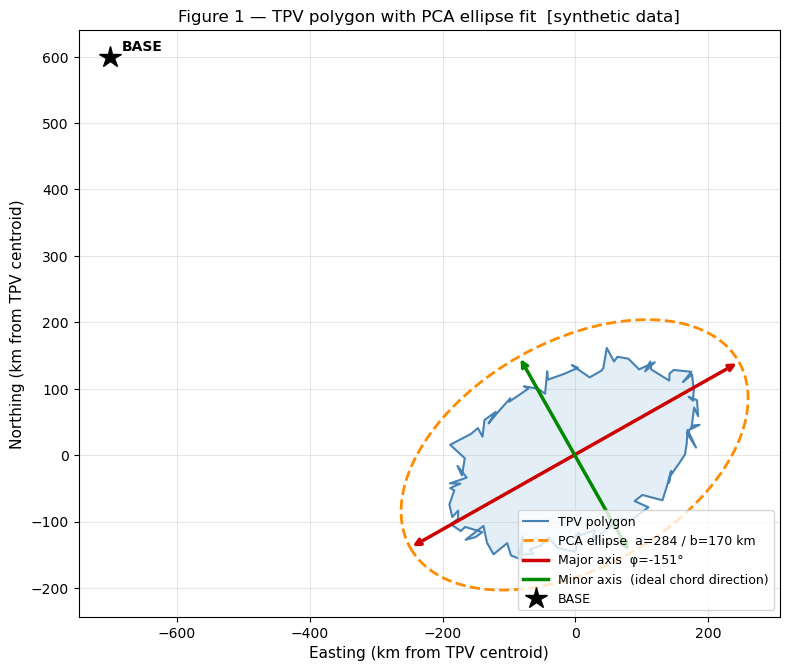

In [4]:
center, a_fit, b_fit, phi_fit = fit_pca_ellipse(TPV_PTS)

print(f'PCA fit :  a = {a_fit:.1f} km   b = {b_fit:.1f} km   φ = {degrees(phi_fit):.1f}°')
print(f'True    :  a = {A_TRUE:.1f} km   b = {B_TRUE:.1f} km   φ = {degrees(PHI_TRUE):.1f}°')

major_dir = np.array([cos(phi_fit),          sin(phi_fit)])
minor_dir = np.array([cos(phi_fit + pi/2),   sin(phi_fit + pi/2)])
print(f'Ideal chord direction (minor axis): '
      f'({minor_dir[0]:.3f}, {minor_dir[1]:.3f})')

# Ellipse outline for plotting
R_fit  = rot2d(phi_fit)
th_e   = np.linspace(0, 2*pi, 300)
ell_xy = (R_fit @ np.vstack([a_fit*np.cos(th_e),
                              b_fit*np.sin(th_e)])).T + center

# ── Figure 1: TPV polygon + PCA ellipse ──────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.55, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5,
        zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=2,
        zorder=3, label=f'PCA ellipse  a={a_fit:.0f} / b={b_fit:.0f} km')

for vec, col, lbl in [
    (major_dir * a_fit, '#cc0000', f'Major axis  φ={degrees(phi_fit):.0f}°'),
    (minor_dir * b_fit, '#008800', 'Minor axis  (ideal chord direction)'),
]:
    ax.annotate('', xy=center+vec, xytext=center-vec,
                arrowprops=dict(arrowstyle='<->', color=col, lw=2.5))
    ax.plot([], [], color=col, lw=2.5, label=lbl)

ax.plot(*BASE, '*', color='black', ms=16, zorder=7, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points',
            xytext=(8, 4), fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km from TPV centroid)', fontsize=11)
ax.set_ylabel('Northing (km from TPV centroid)', fontsize=11)
ax.set_title('Figure 1 — TPV polygon with PCA ellipse fit  [synthetic data]',
             fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Candidate chord generation and budget feasibility

Chords are generated for `N_ANGLE_SAMPLES` directions spanning ±`MAX_ANGLE_DEV_DEG` around the ideal minor-axis direction.
Along the major axis, positions are spaced `MIN_LEG_SPACING_KM` apart.

**Budget feasibility** (straight-line, no obstacles yet):
```
single_trip = dist(BASE → pt_a) + chord length + dist(pt_b → BASE)
remaining   = TOTAL_BUDGET_KM − single_trip
```
A positive `remaining` means there is budget left for a second transect or satellite coincidence.

In [5]:
angle_devs = np.linspace(-MAX_ANGLE_DEV_DEG, MAX_ANGLE_DEV_DEG,
                          N_ANGLE_SAMPLES).tolist()

chords = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs
)

print(f'Candidate chords: {len(chords)}  '
      f'(angle devs {angle_devs[0]:+.0f}° to {angle_devs[-1]:+.0f}°, '
      f'spacing {MIN_LEG_SPACING_KM:.0f} km)')
print()

# Find best routes for 1, 2, 3 chords
routes = {}
for n in [1, 2, 3]:
    r = best_multi_chord_route(BASE, chords, n)
    routes[n] = r
    if r:
        print(f'{n}-chord route:  TPV dist = {r["tpv_dist"]:.0f} km   '
              f'total dist = {r["total_dist"]:.0f} km   '
              f'turns = {r["n_turns"]}   '
              f'remaining = {r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord route:  no feasible combination found')

Candidate chords: 24  (angle devs -5° to +5°, spacing 50 km)

1-chord route:  TPV dist = 244 km   total dist = 2325 km   turns = 2   remaining = 1925 km
2-chord route:  TPV dist = 480 km   total dist = 2616 km   turns = 4   remaining = 1634 km


3-chord route:  TPV dist = 682 km   total dist = 3342 km   turns = 6   remaining = 908 km


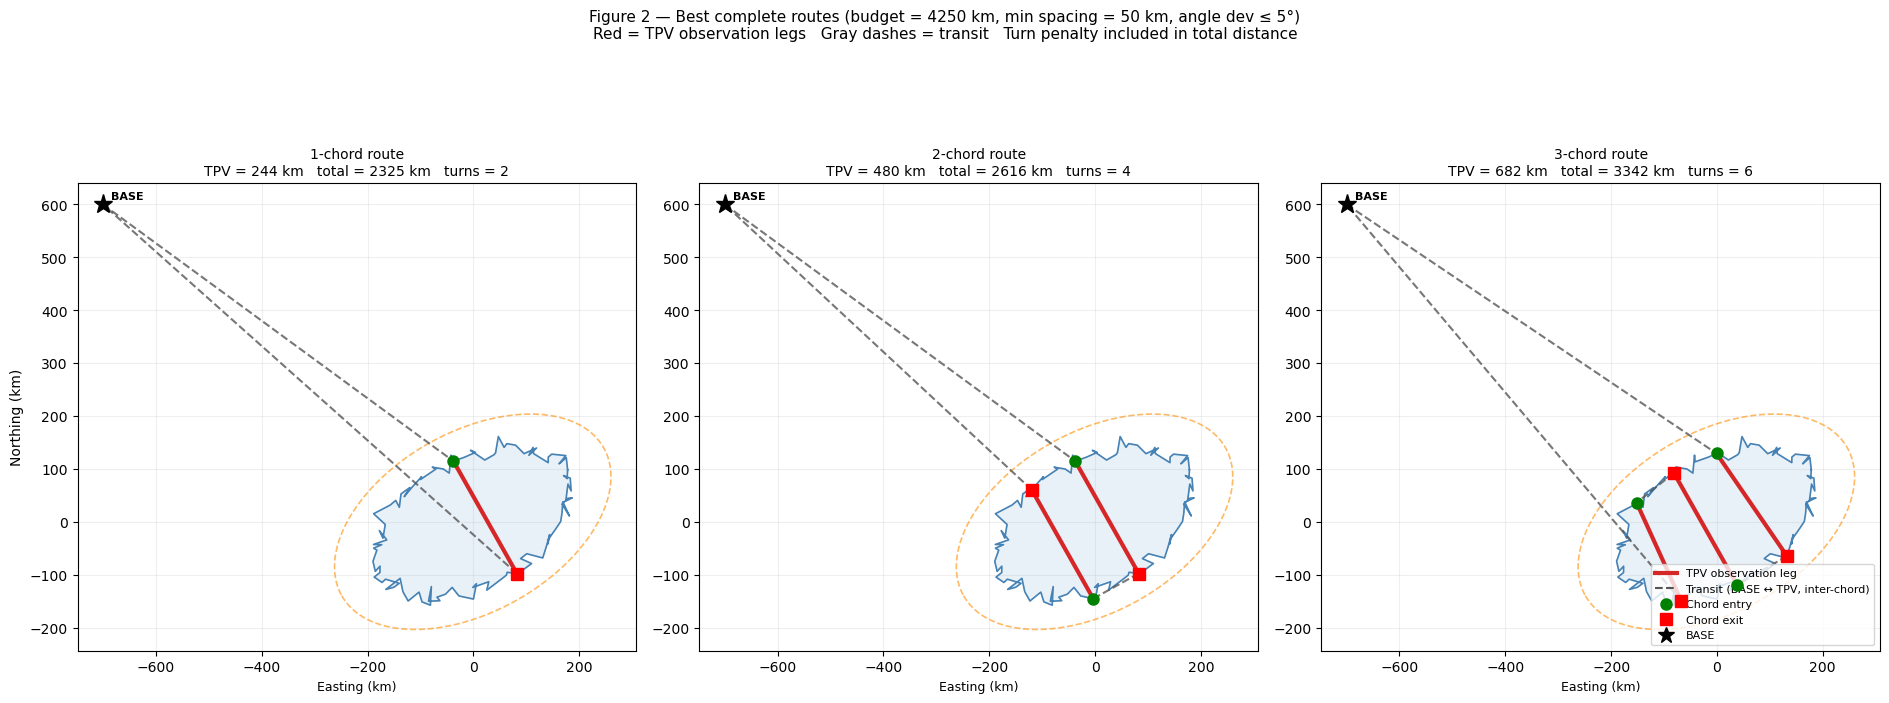

In [6]:
# ── Figure 2: Complete routes for 1, 2, 3 chords ─────────────────────────
def plot_route(ax, route, tpv_pts, ell_xy, base, title):
    """Draw a complete route on ax: transit (dashed gray) + TPV legs (solid blue)."""
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0], closed[:,1], color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0], ell_xy[:,1], '--', color='darkorange',
            lw=1.2, alpha=0.6, zorder=3)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        return

    wpts = route['waypoints']
    segs = route['seg_types']

    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '-', color='#d62728', lw=3, zorder=5, solid_capstyle='round')
        else:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '--', color='#555555', lw=1.5, zorder=4, alpha=0.8)

    # Waypoint markers: entry (circle) and exit (square) for each chord
    tpv_idx = [i for i, s in enumerate(segs) if s == 'tpv']
    for idx in tpv_idx:
        ax.plot(*wpts[idx],   'o', color='green', ms=8, zorder=6)
        ax.plot(*wpts[idx+1], 's', color='red',   ms=8, zorder=6)

    # BASE marker
    ax.plot(*base, '*', color='black', ms=14, zorder=7)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')

    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'{title}\n'
        f'TPV = {route["tpv_dist"]:.0f} km   '
        f'total = {route["total_dist"]:.0f} km   '
        f'turns = {route["n_turns"]}',
        fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, n in zip(axes, [1, 2, 3]):
    plot_route(ax, routes[n], TPV_PTS, ell_xy, BASE, f'{n}-chord route')
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)

# Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#d62728', lw=3,  label='TPV observation leg'),
    Line2D([0], [0], color='#555555', lw=1.5, ls='--', label='Transit (BASE ↔ TPV, inter-chord)'),
    Line2D([0], [0], marker='o', color='green', ms=8, ls='none', label='Chord entry'),
    Line2D([0], [0], marker='s', color='red',   ms=8, ls='none', label='Chord exit'),
    Line2D([0], [0], marker='*', color='black', ms=12, ls='none', label='BASE'),
]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 2 — Best complete routes (budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'min spacing = {MIN_LEG_SPACING_KM:.0f} km, '
    f'angle dev ≤ {MAX_ANGLE_DEV_DEG:.0f}°)\n'
    'Red = TPV observation legs   Gray dashes = transit   '
    'Turn penalty included in total distance',
    fontsize=11)
plt.tight_layout()
plt.show()

---

## Module 2 — Obstacle avoidance & ATC penalty

Two new zone types are loaded here (synthetic polygons — replace with real shapefiles):

| Zone | Effect |
|------|--------|
| **Restricted Airspace** | Hard constraint — route cannot enter |
| **ATC Zone** | Soft penalty — distance inside × `ATC_PENALTY_FACTOR` |

**Approach — Visibility Graph:**
1. Nodes: BASE, all TPV chord endpoints, all polygon vertices (Restricted + ATC)
2. Edges: every pair of nodes whose straight-line segment does not cross any Restricted Airspace polygon
3. Edge cost: straight-line distance × ATC penalty for the fraction inside any ATC Zone
4. Shortest path (Dijkstra) gives the obstacle-avoiding, penalty-weighted transit between any two points

`build_route` is updated to call `obs_dist(p, q)` instead of `straight_dist(p, q)`.

Restricted Airspace polygons : 2
ATC Zone polygons            : 2


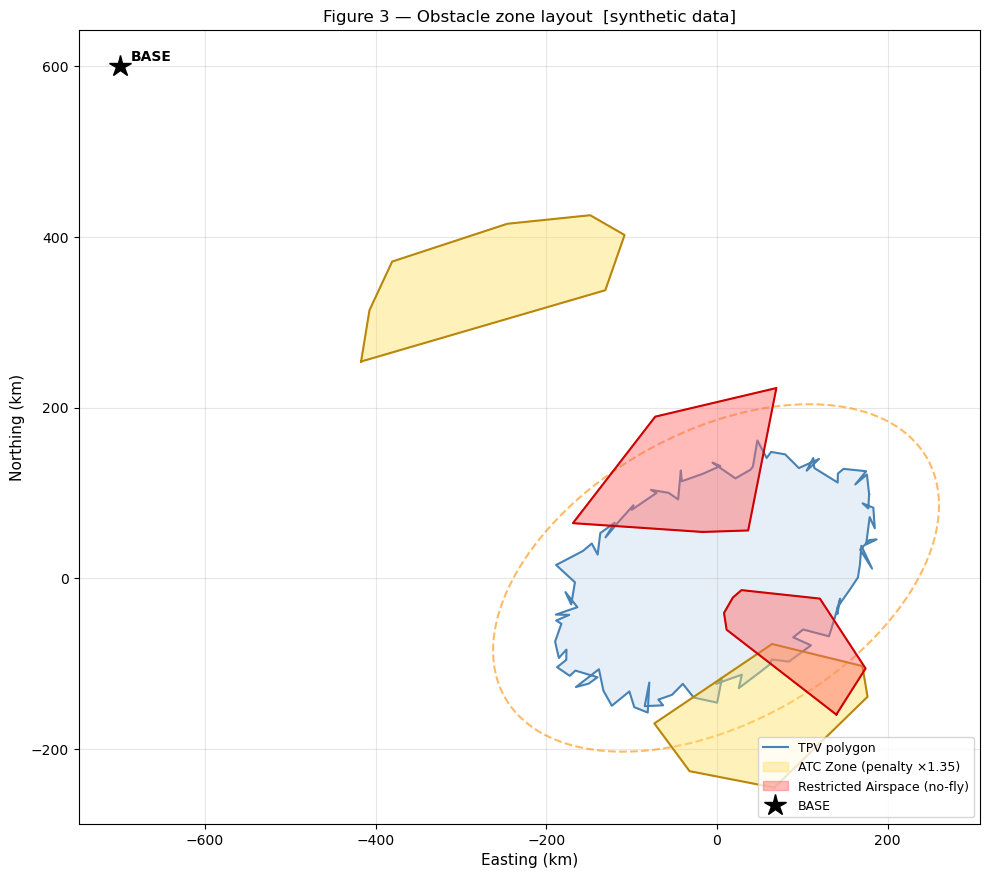

In [7]:
import heapq
from shapely.geometry import MultiPolygon, MultiPoint
from shapely.ops import unary_union

# ── Synthetic obstacle zones (replace with gpd.read_file(...) for real data) ──
#
# To load real shapefiles:
#   restricted_gdf = gpd.read_file(r'path\to\restricted_airspace.shp').to_crs(local_crs)
#   atc_gdf        = gpd.read_file(r'path\to\atc_zones.shp').to_crs(local_crs)
#   then convert to local km frame (same transform used for TPV_PTS)

def make_irregular_poly(cx, cy, radius_x, radius_y, n_pts=10, angle_deg=0., seed=0):
    """Irregular convex polygon roughly fitting radius_x × radius_y, rotated by angle_deg."""
    rng = np.random.RandomState(seed)
    raw_angles = np.sort(rng.uniform(0, 2*pi, n_pts))
    r = rng.uniform(0.55, 1.0, n_pts)
    pts = np.column_stack([r * radius_x * np.cos(raw_angles),
                           r * radius_y * np.sin(raw_angles)])
    R = rot2d(radians(angle_deg))
    pts = (R @ pts.T).T + np.array([cx, cy])
    return MultiPoint(pts).convex_hull

# Restricted Airspace — hard no-fly zones (red)
# Positioned to partially overlap the TPV polygon so some candidate chords are invalidated.
restricted_polys = [
    make_irregular_poly(-30,  130, 160, 100, angle_deg=25., seed=7),   # upper-left, cuts into TPV
    make_irregular_poly( 90,  -80, 110,  80, angle_deg=-20., seed=8),  # lower-right, near TPV edge
]

# ATC Zones — flyable but penalised (yellow)
# Positioned on likely transit corridors between BASE and TPV.
atc_polys = [
    make_irregular_poly(-250, 300, 200, 130, angle_deg=15., seed=9),   # BASE → TPV transit corridor
    make_irregular_poly(  50, -160, 150,  90, angle_deg= 5., seed=10), # below TPV
]

restricted_union = unary_union(restricted_polys)
atc_union        = unary_union(atc_polys)

print(f'Restricted Airspace polygons : {len(restricted_polys)}')
print(f'ATC Zone polygons            : {len(atc_polys)}')

# ── Figure 3: Zone layout ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

closed = np.vstack([TPV_PTS, TPV_PTS[0]])
ax.fill(TPV_PTS[:,0], TPV_PTS[:,1], color='#cfe0f0', alpha=0.5, zorder=1)
ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.5, zorder=2, label='TPV polygon')
ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.5, alpha=0.6, zorder=3)

for poly in atc_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ffe066', alpha=0.45, zorder=4)
    ax.plot(xs, ys, color='#b8860b', lw=1.5, zorder=5)
ax.fill([], [], color='#ffe066', alpha=0.45,
        label=f'ATC Zone (penalty ×{ATC_PENALTY_FACTOR})')

for poly in restricted_polys:
    xs, ys = poly.exterior.xy
    ax.fill(xs, ys, color='#ff6666', alpha=0.45, zorder=6)
    ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)
ax.fill([], [], color='#ff6666', alpha=0.45, label='Restricted Airspace (no-fly)')

ax.plot(*BASE, '*', color='black', ms=16, zorder=10, label='BASE')
ax.annotate('BASE', BASE, textcoords='offset points', xytext=(8, 4),
            fontsize=10, fontweight='bold')

ax.set_aspect('equal')
ax.set_xlabel('Easting (km)', fontsize=11)
ax.set_ylabel('Northing (km)', fontsize=11)
ax.set_title('Figure 3 — Obstacle zone layout  [synthetic data]', fontsize=12)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# ── Re-generate candidate chords filtered against restricted airspace ─────
# Chords whose segments enter any restricted polygon are discarded here,
# so the observation legs themselves never cross a no-fly zone.
chords_obs = generate_candidate_chords(
    tpv_poly, center, a_fit, phi_fit,
    min_spacing=MIN_LEG_SPACING_KM,
    angle_devs_deg=angle_devs,
    restricted_geom=restricted_union,
)
print(f'Candidate chords: {len(chords)} total → {len(chords_obs)} after restricted-airspace filter')

# ── Visibility graph construction ─────────────────────────────────────────

def build_visibility_graph(nodes, restricted, atc):
    """Build a weighted visibility graph over a list of (x,y) nodes.

    Edges connect every pair of nodes whose segment does not cross restricted airspace.
    Edge weight = effective distance (ATC penalty applied to in-zone portions).

    Returns: adj — dict mapping node_index → list of (neighbour_index, cost).
    """
    n = len(nodes)
    adj = {i: [] for i in range(n)}
    for i in range(n):
        for j in range(i + 1, n):
            p1, p2 = nodes[i], nodes[j]
            if seg_crosses_restricted(p1, p2, restricted):
                continue
            cost = seg_atc_cost(p1, p2, atc)
            adj[i].append((j, cost))
            adj[j].append((i, cost))
    return adj

def dijkstra(adj, src, dst):
    """Shortest path from src to dst index in adjacency dict.
    Returns (cost, path_indices) or (inf, []) if unreachable.
    """
    dist = {src: 0.0}
    prev = {src: None}
    heap = [(0.0, src)]
    while heap:
        d, u = heapq.heappop(heap)
        if d > dist.get(u, float('inf')):
            continue
        if u == dst:
            break
        for v, w in adj[u]:
            nd = d + w
            if nd < dist.get(v, float('inf')):
                dist[v] = nd
                prev[v] = u
                heapq.heappush(heap, (nd, v))
    if dst not in dist:
        return float('inf'), []
    path, cur = [], dst
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    return dist[dst], list(reversed(path))


def polygon_vertices(polys):
    verts = []
    for poly in polys:
        coords = list(poly.exterior.coords)[:-1]
        verts.extend(coords)
    return [np.array(v) for v in verts]

# Graph nodes: BASE + filtered chord endpoints + polygon vertices
chord_endpoints = []
for c in chords_obs:
    chord_endpoints.extend([c['pt_a'], c['pt_b']])

all_nodes = (
    [BASE]
    + chord_endpoints
    + polygon_vertices(restricted_polys)
    + polygon_vertices(atc_polys)
)
all_nodes = [np.asarray(n, float) for n in all_nodes]

BASE_IDX = 0
chord_node_idx = {}
for k, c in enumerate(chords_obs):
    base_off = 1 + 2 * k
    chord_node_idx[(k, 'a')] = base_off
    chord_node_idx[(k, 'b')] = base_off + 1

print(f'Visibility graph: {len(all_nodes)} nodes')
print('Building edges (checking restricted airspace crossings)...')

adj = build_visibility_graph(all_nodes, restricted_union, atc_union)

n_edges = sum(len(v) for v in adj.values()) // 2
print(f'Done: {n_edges} valid edges')

Candidate chords: 24 total → 13 after restricted-airspace filter
Visibility graph: 52 nodes
Building edges (checking restricted airspace crossings)...
Done: 615 valid edges


In [9]:
# ── Obstacle-aware transit and updated route builder ──────────────────────

def node_idx(pt):
    """Find the index of pt in all_nodes (exact match)."""
    for i, n in enumerate(all_nodes):
        if np.allclose(n, pt, atol=1e-6):
            return i
    return None

def obs_transit(p, q):
    """Obstacle-avoiding effective distance from p to q via Dijkstra on visibility graph.
    Returns (cost, waypoint_array).
    """
    i, j = node_idx(p), node_idx(q)
    if i is None or j is None:
        return float('inf'), np.array([p, q])
    cost, path_idx = dijkstra(adj, i, j)
    wpts = np.array([all_nodes[k] for k in path_idx])
    return cost, wpts


def build_route_obs(base, ordered_chords):
    """Complete route with obstacle-aware transits.

    Transit segments are routed via the visibility graph (avoiding restricted airspace,
    penalising ATC zones). Turn penalty is computed once across the full waypoint
    sequence using count_turns_in_path — counting every direction change ≥
    TURN_THRESHOLD_DEG, including visibility-graph detour bends.
    """
    pos  = np.asarray(base, float)
    wpts = [pos.copy()]
    segs = []
    total_dist = tpv_dist = 0.0

    for c in ordered_chords:
        pt_a = np.asarray(c['pt_a'], float)
        pt_b = np.asarray(c['pt_b'], float)

        # Choose entry endpoint with cheaper obstacle-aware transit
        cost_a, wpts_a = obs_transit(pos, pt_a)
        cost_b, wpts_b = obs_transit(pos, pt_b)

        if cost_a <= cost_b:
            entry, exit_, transit_cost, transit_wpts = pt_a, pt_b, cost_a, wpts_a
        else:
            entry, exit_, transit_cost, transit_wpts = pt_b, pt_a, cost_b, wpts_b

        if transit_cost == float('inf'):
            return None   # no valid path to this chord

        # Transit to chord entry (intermediate obstacle-detour waypoints included)
        total_dist += transit_cost
        for wp in transit_wpts[1:]:    # transit_wpts[0] == pos, already in wpts
            wpts.append(wp)
            segs.append('transit')

        # Chord observation leg inside TPV
        total_dist += c['length']
        tpv_dist   += c['length']
        wpts.append(exit_)
        segs.append('tpv')

        pos = exit_

    # Return to BASE
    return_cost, return_wpts = obs_transit(pos, base)
    if return_cost == float('inf'):
        return None
    total_dist += return_cost
    for wp in return_wpts[1:]:
        wpts.append(wp)
        segs.append('transit')

    # Count ALL direction changes across the full waypoint sequence
    n_turns     = count_turns_in_path(wpts)
    total_dist += n_turns * TURN_PENALTY_KM

    return dict(
        waypoints=np.array(wpts),
        seg_types=segs,
        total_dist=total_dist,
        tpv_dist=tpv_dist,
        n_turns=n_turns,
        feasible=total_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - total_dist,
    )


def best_multi_chord_route_obs(base, chords, n_chords,
                                min_spacing=MIN_LEG_SPACING_KM):
    """Like best_multi_chord_route but uses obstacle-aware transits."""
    best = None
    best_tpv = -1.0
    for combo in combinations(chords, n_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_chords > 1 and any(
            offsets[i+1] - offsets[i] < min_spacing
            for i in range(n_chords - 1)
        ):
            continue
        for ordered in [
            sorted(combo, key=lambda c:  c['offset']),
            sorted(combo, key=lambda c: -c['offset']),
        ]:
            route = build_route_obs(base, ordered)
            if route and route['feasible'] and route['tpv_dist'] > best_tpv:
                best_tpv = route['tpv_dist']
                best = route
    return best


print('Obstacle-aware route builder ready.')

# Find best routes with obstacle avoidance (using filtered chords_obs)
routes_obs = {}
for n in [1, 2, 3]:
    r = best_multi_chord_route_obs(BASE, chords_obs, n)
    routes_obs[n] = r
    if r:
        print(f'{n}-chord (obs): TPV = {r["tpv_dist"]:.0f} km   '
              f'total = {r["total_dist"]:.0f} km   '
              f'turns = {r["n_turns"]}   '
              f'remaining = {r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord (obs): no feasible route found')

Obstacle-aware route builder ready.
1-chord (obs): TPV = 236 km   total = 2497 km   turns = 4   remaining = 1753 km


2-chord (obs): TPV = 425 km   total = 3634 km   turns = 11   remaining = 616 km


3-chord (obs): TPV = 540 km   total = 4004 km   turns = 11   remaining = 246 km


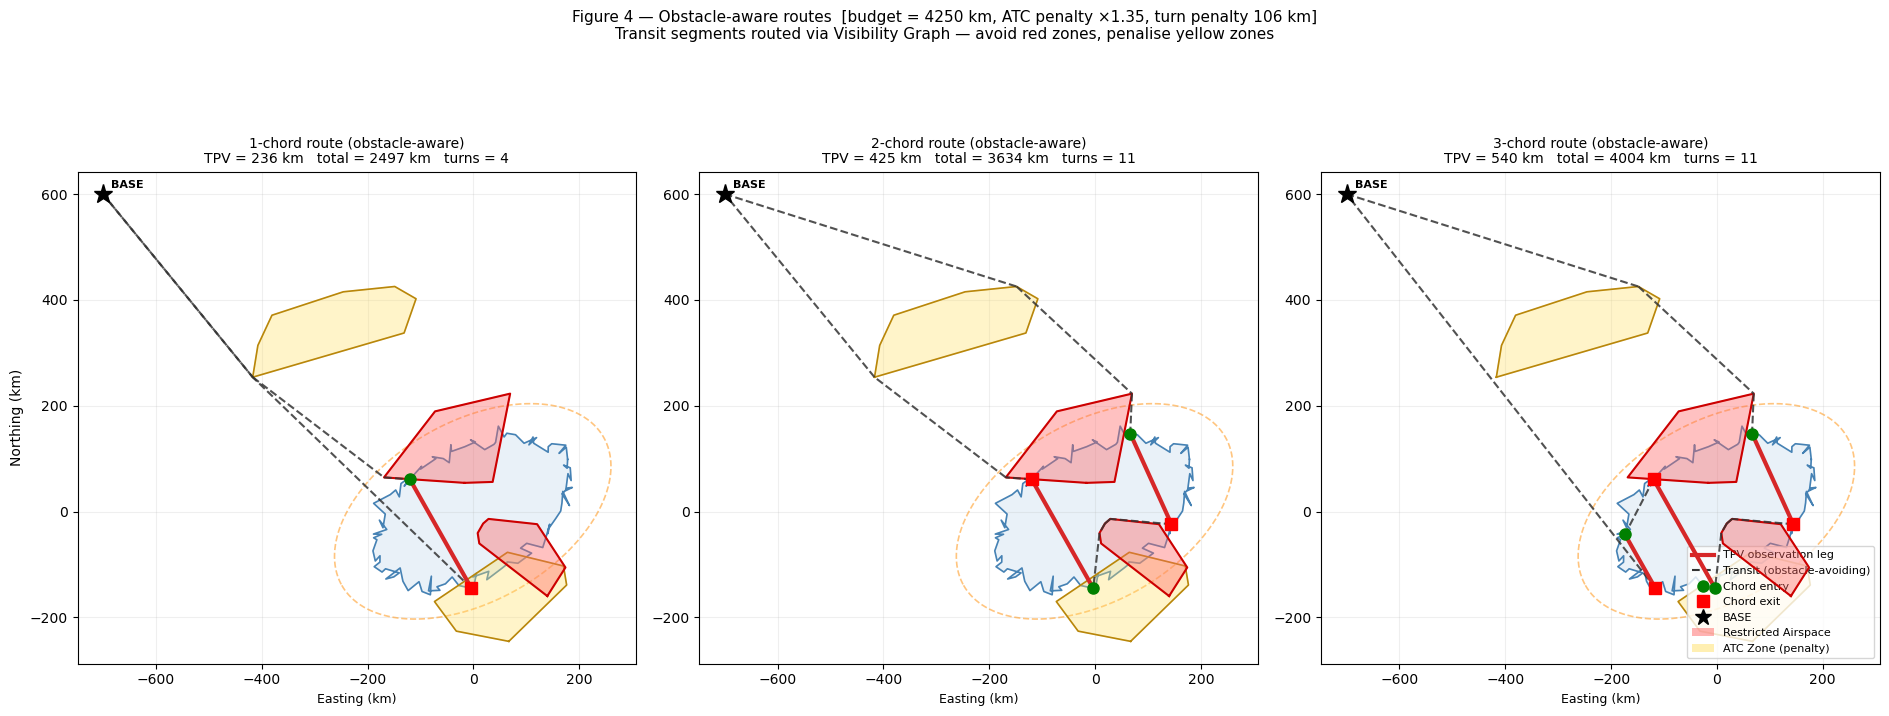

In [10]:
# ── Figure 4: Complete obstacle-aware routes ──────────────────────────────
def plot_route_obs(ax, route, tpv_pts, ell_xy, base,
                   restricted_polys, atc_polys, title):
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.2, alpha=0.5, zorder=3)

    for poly in atc_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ffe066', alpha=0.35, zorder=4)
        ax.plot(xs, ys, color='#b8860b', lw=1.2, zorder=5)

    for poly in restricted_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ff6666', alpha=0.40, zorder=6)
        ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2)
        return

    wpts = route['waypoints']
    segs = route['seg_types']

    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '-', color='#d62728', lw=3, zorder=9, solid_capstyle='round')
        else:
            ax.plot([p1[0], p2[0]], [p1[1], p2[1]],
                    '--', color='#333333', lw=1.5, zorder=8, alpha=0.85)

    tpv_idx = [i for i, s in enumerate(segs) if s == 'tpv']
    for idx in tpv_idx:
        ax.plot(*wpts[idx],   'o', color='green', ms=8, zorder=10)
        ax.plot(*wpts[idx+1], 's', color='red',   ms=8, zorder=10)

    ax.plot(*base, '*', color='black', ms=14, zorder=11)
    ax.annotate('BASE', base, textcoords='offset points',
                xytext=(6, 4), fontsize=8, fontweight='bold')
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'{title}\n'
        f'TPV = {route["tpv_dist"]:.0f} km   '
        f'total = {route["total_dist"]:.0f} km   '
        f'turns = {route["n_turns"]}',
        fontsize=10)


fig, axes = plt.subplots(1, 3, figsize=(19, 8))

for ax, n in zip(axes, [1, 2, 3]):
    plot_route_obs(ax, routes_obs[n], TPV_PTS, ell_xy, BASE,
                   restricted_polys, atc_polys, f'{n}-chord route (obstacle-aware)')
    ax.set_xlabel('Easting (km)', fontsize=9)

axes[0].set_ylabel('Northing (km)', fontsize=10)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0],[0], color='#d62728', lw=3,             label='TPV observation leg'),
    Line2D([0],[0], color='#333333', lw=1.5, ls='--',  label='Transit (obstacle-avoiding)'),
    Line2D([0],[0], marker='o', color='green', ms=8, ls='none', label='Chord entry'),
    Line2D([0],[0], marker='s', color='red',   ms=8, ls='none', label='Chord exit'),
    Line2D([0],[0], marker='*', color='black', ms=12, ls='none', label='BASE'),
    Patch(facecolor='#ff6666', alpha=0.5, label='Restricted Airspace'),
    Patch(facecolor='#ffe066', alpha=0.5, label='ATC Zone (penalty)'),
]
axes[2].legend(handles=legend_elements, fontsize=8, loc='lower right')

fig.suptitle(
    f'Figure 4 — Obstacle-aware routes  [budget = {TOTAL_BUDGET_KM:.0f} km, '
    f'ATC penalty ×{ATC_PENALTY_FACTOR}, turn penalty {TURN_PENALTY_KM:.0f} km]\n'
    'Transit segments routed via Visibility Graph — avoid red zones, penalise yellow zones',
    fontsize=11)
plt.tight_layout()
plt.show()

---

## Module 3 — Satellite coincidence segment

The aircraft should fly along the **EarthCARE ground track** for at least `T_MIN_SAT_MIN` minutes to enable coincident remote-sensing measurements. This is a secondary objective (TPV transects take priority).

| Variable | Meaning |
|----------|---------|
| `SAT_DIR` | Unit vector along satellite travel direction |
| `SAT_REF_PT` | Reference point on the ground track (inside or near TPV) |
| `T_SAT_H` | Time at which the satellite passes `SAT_REF_PT` (hours after departure) |
| `SAT_MIN_LENGTH_KM` | Minimum coincidence length = `T_MIN_SAT_MIN / 60 × speed` ≈ 142 km |

**Approach:**
1. Clip the satellite ground track against restricted airspace; take the longest valid sub-segment ≥ `SAT_MIN_LENGTH_KM`
2. Add the satellite segment endpoints to the visibility graph
3. Enumerate route orderings: satellite-first or satellite-last relative to the TPV chords
4. Back-calculate departure time: `T_dep = T_sat − d(BASE → sat midpoint) / speed`

**Why geometric distance for timing?** The ATC penalty represents increased fuel burn at low altitude, not extra flight time. Turns add time (`TURN_PENALTY_MIN` min each). Both corrections are applied to effective distance (budget), but actual clock time uses only the geometric path length.

In [11]:
# ── Satellite ground track parameters ─────────────────────────────────────
SAT_MIN_LENGTH_KM = T_MIN_SAT_MIN / 60.0 * AIRCRAFT_SPEED_KMH   # min coincidence length (km)

# Synthetic EarthCARE track: direction differs clearly from TPV chord direction
sat_phi    = phi_fit + radians(55.)                        # 55° offset from TPV major axis
SAT_DIR    = np.array([cos(sat_phi), sin(sat_phi)])        # satellite travel direction (unit vec)
SAT_REF_PT = np.asarray(center) + np.array([20., -40.])   # reference point on track (inside TPV)
T_SAT_H    = 2.0   # satellite passes SAT_REF_PT at t = 2.0 h after BASE departure (nominal)

# Full ground track for visualisation only (1 000 km, not constrained to valid airspace)
sat_full_line = LineString([SAT_REF_PT - 500.*SAT_DIR, SAT_REF_PT + 500.*SAT_DIR])

print(f'Satellite track direction : {degrees(sat_phi):.1f}° from horizontal')
print(f'Min coincidence           : {SAT_MIN_LENGTH_KM:.0f} km  ({T_MIN_SAT_MIN:.0f} min)')
print(f'T_SAT reference           : {T_SAT_H:.2f} h after departure')

# ── Find a valid satellite segment of exactly SAT_MIN_LENGTH_KM ───────────
# Start at SAT_REF_PT; shift along track (in steps) until the segment is clear
# of restricted airspace.
half = SAT_MIN_LENGTH_KM / 2.0
sat_pt_a = sat_pt_b = None
for shift_km in np.concatenate([[0.], np.arange(20., 300., 20.), np.arange(-20., -300., -20.)]):
    ref = SAT_REF_PT + shift_km * SAT_DIR
    pa  = ref - half * SAT_DIR
    pb  = ref + half * SAT_DIR
    if not seg_crosses_restricted(pa, pb, restricted_union):
        sat_pt_a, sat_pt_b = np.asarray(pa, float), np.asarray(pb, float)
        sat_length = SAT_MIN_LENGTH_KM
        if shift_km != 0.:
            print(f'Satellite segment shifted {shift_km:+.0f} km along track to clear restricted zone')
        break

if sat_pt_a is None:
    raise RuntimeError('Cannot place satellite segment — all positions cross restricted airspace')

print(f'Valid satellite segment   : {sat_length:.0f} km  '
      f'({sat_pt_a} → {sat_pt_b})')

# ── Extend visibility graph to include satellite segment endpoints ─────────
all_nodes_m3 = all_nodes + [sat_pt_a, sat_pt_b]
print(f'\nBuilding extended visibility graph ({len(all_nodes_m3)} nodes)...')
adj_m3   = build_visibility_graph(all_nodes_m3, restricted_union, atc_union)
n_edg_m3 = sum(len(v) for v in adj_m3.values()) // 2
print(f'Done: {n_edg_m3} edges')

def node_idx_m3(pt):
    for i, n in enumerate(all_nodes_m3):
        if np.allclose(n, pt, atol=1e-6):
            return i
    return None

def obs_transit_m3(p, q):
    """Obstacle-avoiding transit using the extended M3 visibility graph."""
    i, j = node_idx_m3(p), node_idx_m3(q)
    if i is None or j is None:
        return float('inf'), np.array([p, q])
    cost, path_idx = dijkstra(adj_m3, i, j)
    if not path_idx:
        return float('inf'), np.array([p, q])
    return cost, np.array([all_nodes_m3[k] for k in path_idx])


# ── Route builder: TPV chords + satellite coincidence ─────────────────────
def build_route_m3(base, tpv_chords, T_sat_h, sat_first=False):
    """Complete route with obstacle-aware transits and satellite coincidence segment.

    - tpv_chords  : ordered list of chord dicts (from chords_obs)
    - T_sat_h     : satellite passes SAT_REF_PT at this time (hours after departure)
    - sat_first   : if True, fly satellite segment before TPV chords

    Departure time T_dep is back-calculated so the aircraft reaches the
    satellite segment midpoint exactly at T_sat_h.  Effective distance
    (budget) uses ATC penalty; actual timing uses geometric distance only.
    """
    tpv_legs = [('tpv', c['pt_a'], c['pt_b'], c['length']) for c in tpv_chords]
    sat_leg  = [('sat', sat_pt_a,  sat_pt_b,  sat_length)]
    legs     = sat_leg + tpv_legs if sat_first else tpv_legs + sat_leg

    pos      = np.asarray(base, float)
    wpts     = [pos.copy()]; segs = []
    eff_dist = geo_dist = tpv_dist = sat_dist_flew = 0.0
    geo_to_sat_mid = None

    for leg_type, pt_a, pt_b, length in legs:
        pt_a, pt_b = np.asarray(pt_a, float), np.asarray(pt_b, float)

        cost_a, wpts_a = obs_transit_m3(pos, pt_a)
        cost_b, wpts_b = obs_transit_m3(pos, pt_b)
        if cost_a <= cost_b:
            entry, exit_, eff_t, t_wpts = pt_a, pt_b, cost_a, wpts_a
        else:
            entry, exit_, eff_t, t_wpts = pt_b, pt_a, cost_b, wpts_b

        if eff_t == float('inf'):
            return None

        # Geometric transit length (actual flight time — ATC penalty is fuel cost, not time)
        geo_t = sum(float(np.linalg.norm(t_wpts[i+1]-t_wpts[i]))
                    for i in range(len(t_wpts)-1))

        eff_dist += eff_t;  geo_dist += geo_t
        for wp in t_wpts[1:]:
            wpts.append(wp); segs.append('transit')

        if leg_type == 'sat':
            geo_to_sat_mid = geo_dist + length / 2.0   # geometric dist to satellite midpoint
            sat_dist_flew += length
        else:
            tpv_dist += length

        eff_dist += length;  geo_dist += length
        wpts.append(exit_); segs.append(leg_type)
        pos = exit_

    # Return to BASE
    ret_cost, ret_wpts = obs_transit_m3(pos, base)
    if ret_cost == float('inf'):
        return None
    ret_geo = sum(float(np.linalg.norm(ret_wpts[i+1]-ret_wpts[i]))
                  for i in range(len(ret_wpts)-1))
    eff_dist += ret_cost;  geo_dist += ret_geo
    for wp in ret_wpts[1:]:
        wpts.append(wp); segs.append('transit')

    n_turns   = count_turns_in_path(wpts)
    eff_dist += n_turns * TURN_PENALTY_KM

    # T_dep: depart early enough to reach satellite segment midpoint exactly at T_sat_h
    T_dep_h = T_sat_h - geo_to_sat_mid / AIRCRAFT_SPEED_KMH

    return dict(
        waypoints=np.array(wpts), seg_types=segs,
        total_dist=eff_dist, tpv_dist=tpv_dist, sat_dist=sat_dist_flew,
        n_turns=n_turns, feasible=eff_dist <= TOTAL_BUDGET_KM,
        budget_remaining=TOTAL_BUDGET_KM - eff_dist,
        T_dep_h=T_dep_h,
    )


def best_route_m3(base, chords, n_tpv_chords, T_sat_h,
                  min_spacing=MIN_LEG_SPACING_KM):
    """Best route with n_tpv_chords TPV legs + satellite coincidence.
    Tries all chord combinations, both orderings, sat-first and sat-last.
    Primary criterion: feasibility; secondary: maximum TPV distance.
    """
    best = None; best_tpv = -1.0
    for combo in combinations(chords, n_tpv_chords):
        offsets = sorted(c['offset'] for c in combo)
        if n_tpv_chords > 1 and any(
            offsets[i+1]-offsets[i] < min_spacing for i in range(n_tpv_chords-1)
        ):
            continue
        for ordered in [sorted(combo, key=lambda c:  c['offset']),
                        sorted(combo, key=lambda c: -c['offset'])]:
            for sat_first in [False, True]:
                r = build_route_m3(base, ordered, T_sat_h, sat_first=sat_first)
                if r and r['feasible'] and r['tpv_dist'] > best_tpv:
                    best_tpv = r['tpv_dist']; best = r
    return best


print('\nModule 3 route builder ready.')
routes_m3 = {}
for n in [1, 2, 3]:
    r = best_route_m3(BASE, chords_obs, n, T_SAT_H)
    routes_m3[n] = r
    if r:
        offset_h = r['T_dep_h'] - T_SAT_H
        print(f'{n}-chord+sat: TPV={r["tpv_dist"]:.0f} km  sat={r["sat_dist"]:.0f} km  '
              f'total={r["total_dist"]:.0f} km  turns={r["n_turns"]}  '
              f'T_dep = T_sat {"+" if offset_h >= 0 else ""}{offset_h:.2f} h  '
              f'remaining={r["budget_remaining"]:.0f} km')
    else:
        print(f'{n}-chord+sat: no feasible route')

Satellite track direction : -95.5° from horizontal
Min coincidence           : 142 km  (10 min)
T_SAT reference           : 2.00 h after departure
Satellite segment shifted +100 km along track to clear restricted zone
Valid satellite segment   : 142 km  ([ 16.02535354 -68.68989321] → [   2.33304883 -209.69331599])

Building extended visibility graph (54 nodes)...
Done: 666 edges

Module 3 route builder ready.


1-chord+sat: TPV=236 km  sat=142 km  total=3005 km  turns=7  T_dep = T_sat -1.39 h  remaining=1245 km


2-chord+sat: TPV=425 km  sat=142 km  total=4041 km  turns=10  T_dep = T_sat -1.24 h  remaining=209 km


3-chord+sat: TPV=410 km  sat=142 km  total=4247 km  turns=9  T_dep = T_sat -2.47 h  remaining=3 km


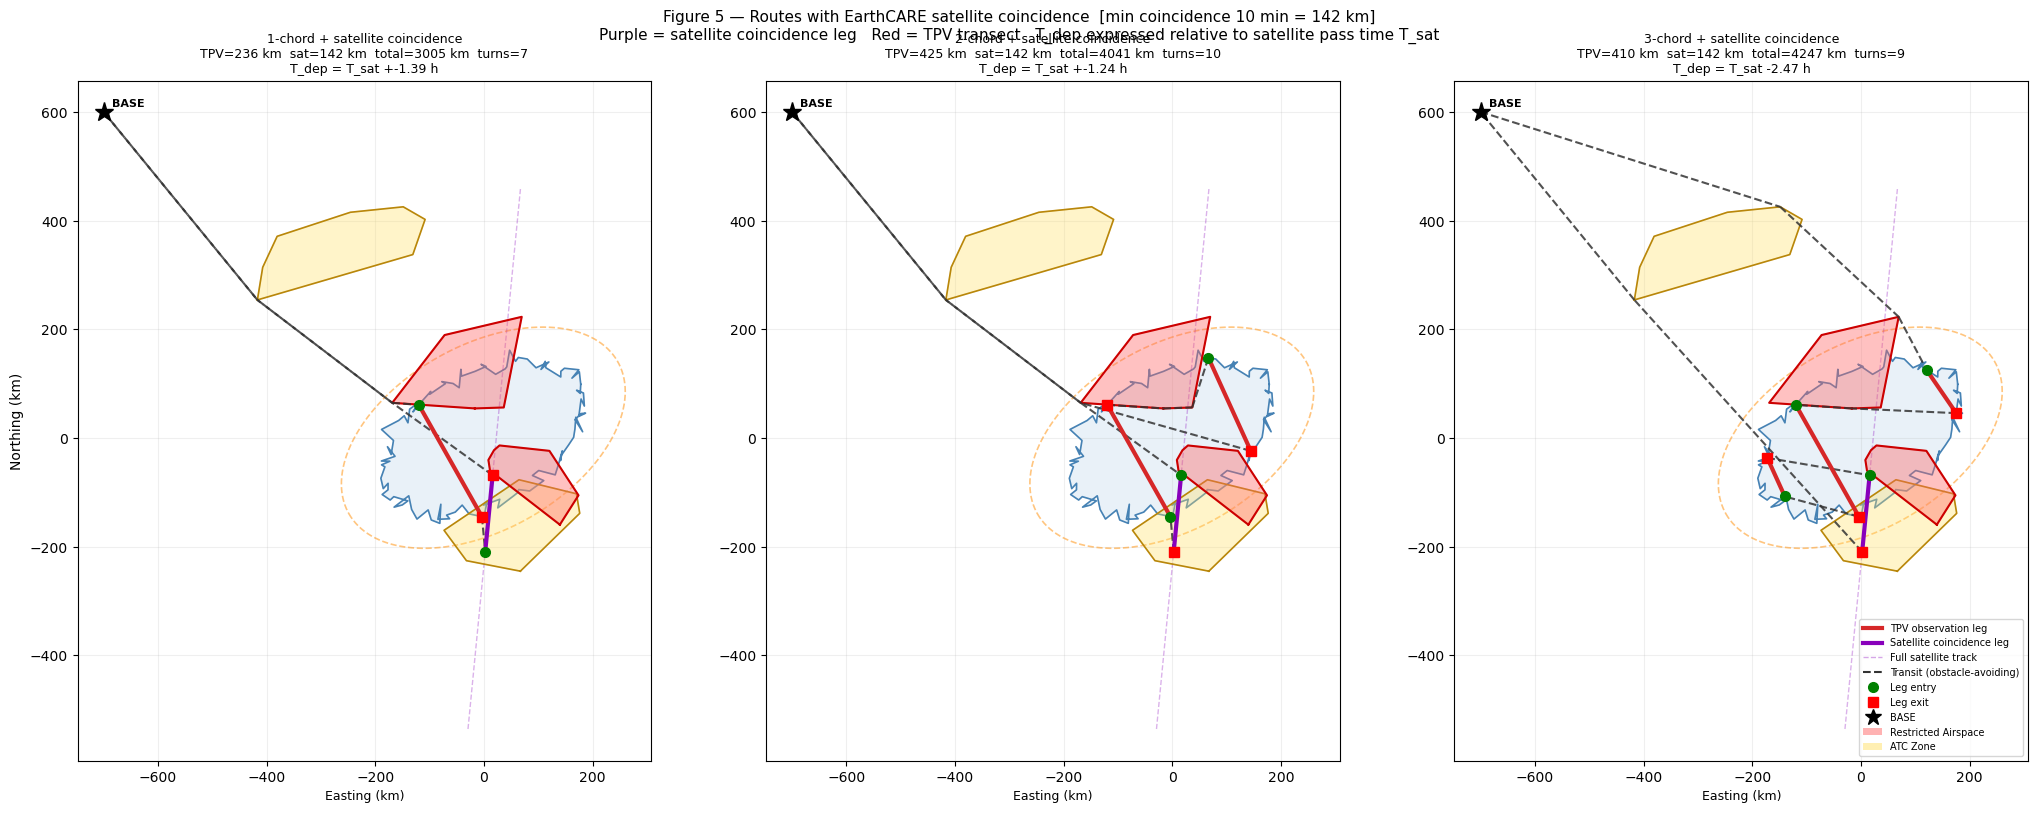

In [12]:
# ── Figure 5: Complete routes with satellite coincidence ───────────────────
def plot_route_m3(ax, route, tpv_pts, ell_xy, base,
                  restricted_polys, atc_polys,
                  sat_full_line, title):
    closed = np.vstack([tpv_pts, tpv_pts[0]])
    ax.fill(tpv_pts[:,0], tpv_pts[:,1], color='#cfe0f0', alpha=0.45, zorder=1)
    ax.plot(closed[:,0],  closed[:,1],  color='steelblue', lw=1.2, zorder=2)
    ax.plot(ell_xy[:,0],  ell_xy[:,1],  '--', color='darkorange', lw=1.2, alpha=0.5, zorder=3)

    # Satellite full ground track (faint reference line)
    sat_c = np.array(sat_full_line.coords)
    ax.plot(sat_c[:,0], sat_c[:,1], '--', color='#8800bb', lw=1.0, alpha=0.3, zorder=4)

    for poly in atc_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ffe066', alpha=0.35, zorder=4)
        ax.plot(xs, ys, color='#b8860b', lw=1.2, zorder=5)

    for poly in restricted_polys:
        xs, ys = poly.exterior.xy
        ax.fill(xs, ys, color='#ff6666', alpha=0.40, zorder=6)
        ax.plot(xs, ys, color='#cc0000', lw=1.5, zorder=7)

    if route is None:
        ax.set_title(title + '\n(no feasible route)', fontsize=10)
        ax.set_aspect('equal'); ax.grid(True, alpha=0.2); return

    wpts = route['waypoints']
    segs = route['seg_types']
    for i, seg_type in enumerate(segs):
        p1, p2 = wpts[i], wpts[i+1]
        if seg_type == 'tpv':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color='#d62728',
                    lw=3, zorder=9, solid_capstyle='round')
        elif seg_type == 'sat':
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '-', color='#8800bb',
                    lw=3, zorder=9, solid_capstyle='round')
        else:
            ax.plot([p1[0],p2[0]], [p1[1],p2[1]], '--', color='#333333',
                    lw=1.5, zorder=8, alpha=0.85)

    for i, s in enumerate(segs):
        if s in ('tpv', 'sat'):
            ax.plot(*wpts[i],   'o', color='green', ms=7, zorder=10)
            ax.plot(*wpts[i+1], 's', color='red',   ms=7, zorder=10)

    ax.plot(*base, '*', color='black', ms=14, zorder=11)
    ax.annotate('BASE', base, textcoords='offset points', xytext=(6,4),
                fontsize=8, fontweight='bold')
    ax.set_aspect('equal'); ax.grid(True, alpha=0.2)

    T_dep = route.get('T_dep_h', float('nan'))
    T_dep_sign = '+' if T_dep >= 0 else ''
    ax.set_title(
        f'{title}\n'
        f'TPV={route["tpv_dist"]:.0f} km  sat={route["sat_dist"]:.0f} km  '
        f'total={route["total_dist"]:.0f} km  turns={route["n_turns"]}\n'
        f'T_dep = T_sat {T_dep_sign}{T_dep - T_SAT_H:.2f} h',
        fontsize=9)


fig, axes = plt.subplots(1, 3, figsize=(21, 8))
for ax, n in zip(axes, [1, 2, 3]):
    plot_route_m3(ax, routes_m3[n], TPV_PTS, ell_xy, BASE,
                  restricted_polys, atc_polys, sat_full_line,
                  f'{n}-chord + satellite coincidence')
    ax.set_xlabel('Easting (km)', fontsize=9)
axes[0].set_ylabel('Northing (km)', fontsize=10)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
legend_elements = [
    Line2D([0],[0], color='#d62728', lw=3,             label='TPV observation leg'),
    Line2D([0],[0], color='#8800bb', lw=3,             label='Satellite coincidence leg'),
    Line2D([0],[0], color='#8800bb', lw=1, ls='--', alpha=0.35, label='Full satellite track'),
    Line2D([0],[0], color='#333333', lw=1.5, ls='--', label='Transit (obstacle-avoiding)'),
    Line2D([0],[0], marker='o', color='green', ms=7, ls='none', label='Leg entry'),
    Line2D([0],[0], marker='s', color='red',   ms=7, ls='none', label='Leg exit'),
    Line2D([0],[0], marker='*', color='black', ms=12, ls='none', label='BASE'),
    Patch(facecolor='#ff6666', alpha=0.5, label='Restricted Airspace'),
    Patch(facecolor='#ffe066', alpha=0.5, label='ATC Zone'),
]
axes[2].legend(handles=legend_elements, fontsize=7, loc='lower right')

fig.suptitle(
    f'Figure 5 — Routes with EarthCARE satellite coincidence  '
    f'[min coincidence {T_MIN_SAT_MIN:.0f} min = {SAT_MIN_LENGTH_KM:.0f} km]\n'
    'Purple = satellite coincidence leg   Red = TPV transect   '
    'T_dep expressed relative to satellite pass time T_sat',
    fontsize=11)
plt.tight_layout()
plt.show()